## Objective

Evaluate how genomic evaluations for selection indexes (LPI, Pro$), production traits,
conformation traits, and inbreeding changed across birth-year cohorts (2018–2026) in
the evaluated Holstein population (n = 668).

## Scope

This notebook is **descriptive**. Functional subindexes (PROD, HEALTH, L-TYPE, REPRO,
M-ABILITY, ENVIRO), body size and their strategic implications are analysed separately.

## Important methodological note

These figures show changes in the average genomic evaluations of animals included in
the database by year of birth. They do not represent actual milk production, observed
conformation, or population-level genetic trends estimated using a genetic model.

Three further limitations follow from this:

- **Single herd, not a population.** All animals belong to one commercial herd; cohort
  means are not representative of the Canadian Holstein population.
- **Survivorship.** The database contains the animals currently present. Animals culled
  or sold are absent, so earlier cohorts are a **surviving subset**, not the full
  cohort as born.
- **Single evaluation date.** All animals were evaluated on the same date under the
  same models. Differences between cohorts reflect the genetic merit of animals born in
  each year — not evaluations made at the time.

Cohorts before 2018 are excluded: 2013 and 2015 contain one animal each.

In [1]:
# ============================================================
# IMPORT LIBRARIES AND DEFINE VISUAL STYLE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (12, 7),
    "figure.dpi": 130,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "lines.linewidth": 2.5,
    "lines.markersize": 6,
    "legend.frameon": True,
    "font.size": 10
})

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")

df["year"] = pd.to_numeric(df["year"], errors="coerce")

print(f"Animals loaded: {len(df)}")
print(f"Birth years: {int(df['year'].min())}–{int(df['year'].max())}")

Animals loaded: 668
Birth years: 2013–2026


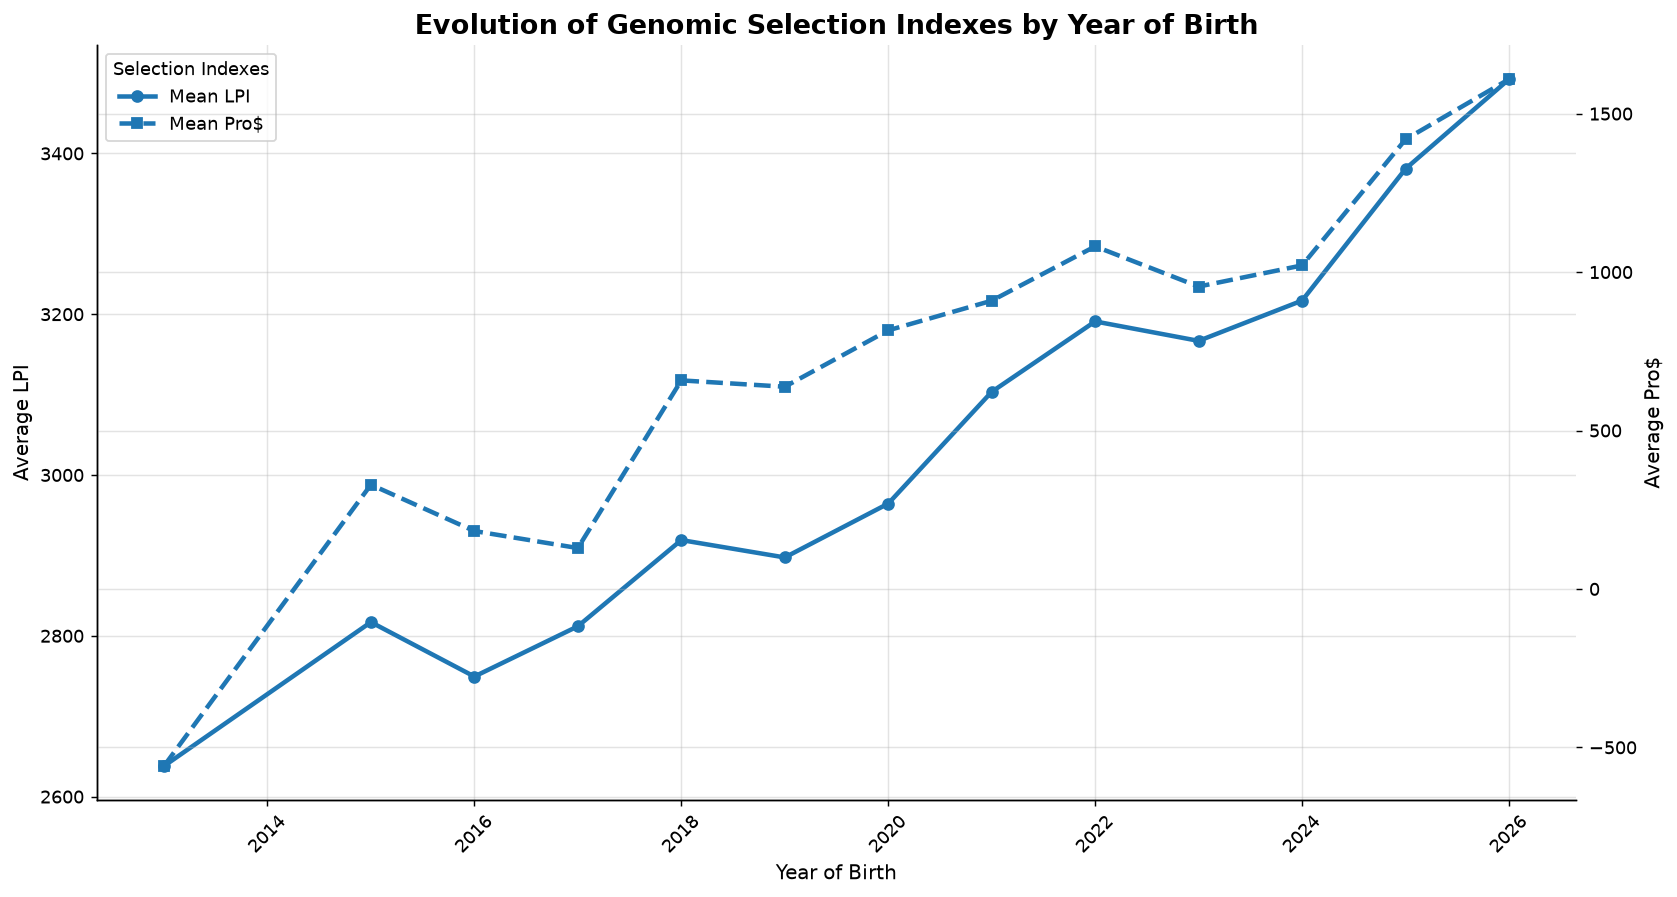

In [3]:
# ============================================================
# LPI AND PRO$ BY YEAR OF BIRTH
# ============================================================

index_trend = (
    df.groupby("year")
      .agg(
          Mean_LPI=("LPI", "mean"),
          Mean_ProDollar=("Pro$", "mean"),
          Animals=("Barn ID", "count")
      )
      .reset_index()
      .sort_values("year")
)

fig, ax1 = plt.subplots(figsize=(13, 7))

line1 = ax1.plot(
    index_trend["year"],
    index_trend["Mean_LPI"],
    marker="o",
    label="Mean LPI"
)

ax1.set_xlabel("Year of Birth")
ax1.set_ylabel("Average LPI")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

line2 = ax2.plot(
    index_trend["year"],
    index_trend["Mean_ProDollar"],
    marker="s",
    linestyle="--",
    label="Mean Pro$"
)

ax2.set_ylabel("Average Pro$")

lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="upper left",
    title="Selection Indexes"
)

ax1.set_title(
    "Evolution of Genomic Selection Indexes by Year of Birth"
)

plt.tight_layout()
plt.show()

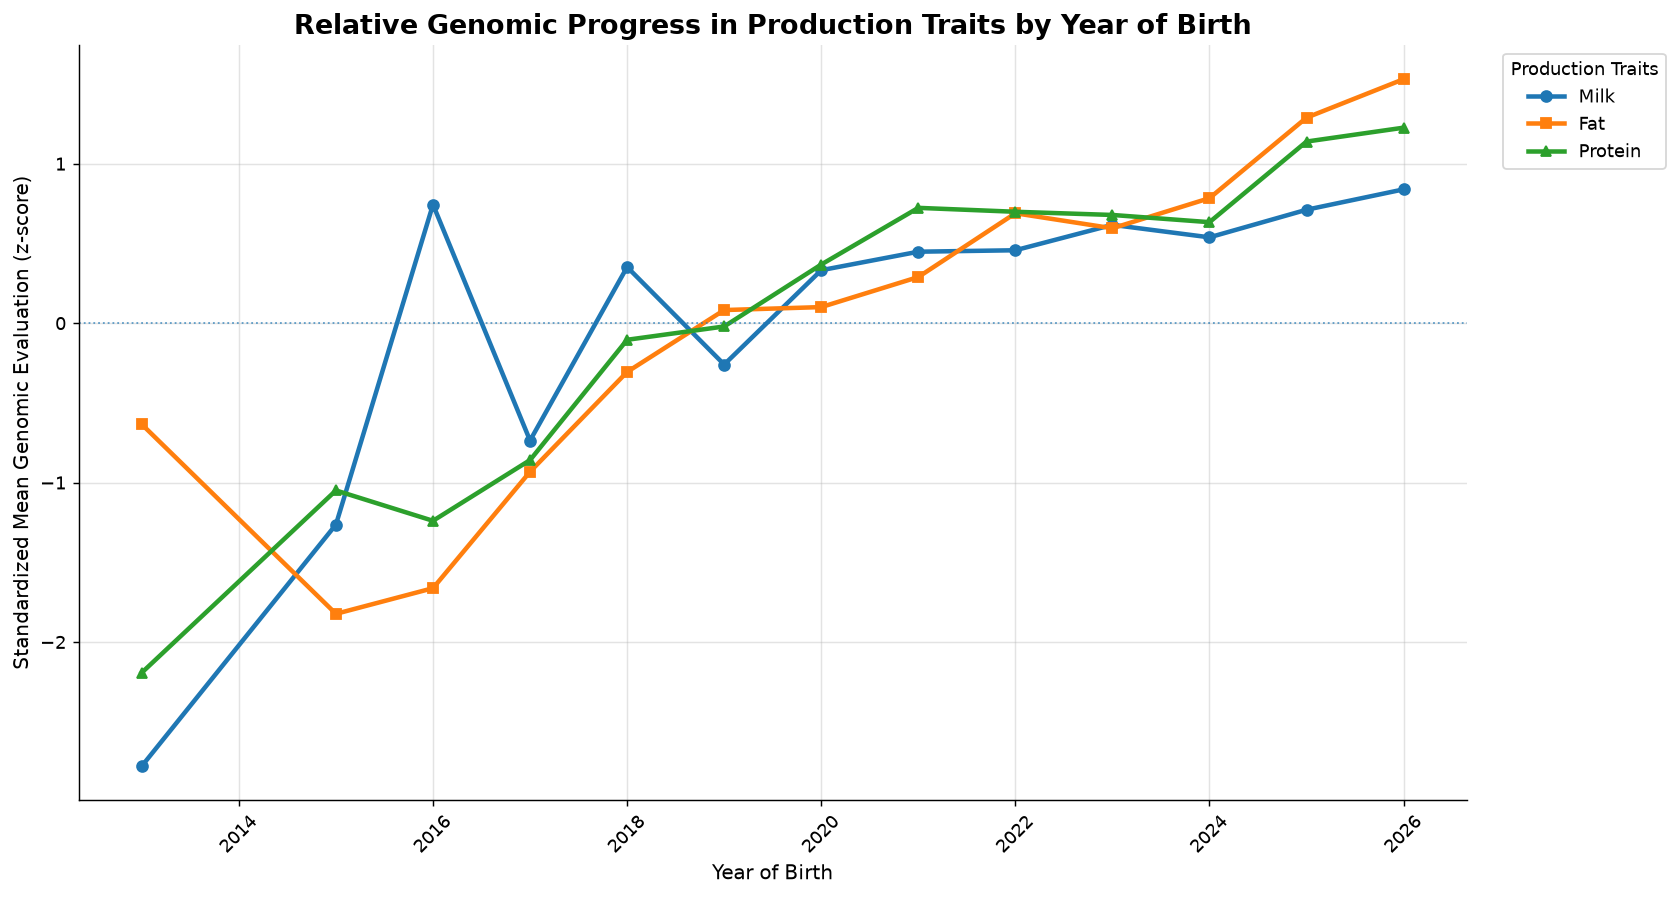

In [4]:
# ============================================================
# STANDARDIZED PRODUCTION TRAIT TRENDS
# ============================================================

production_columns = [
    "Milk (kg)",
    "Fat (kg)",
    "Prot (kg)"
]

production_year = (
    df.groupby("year")[production_columns]
      .mean()
      .sort_index()
)

production_standardized = (
    production_year - production_year.mean()
) / production_year.std(ddof=0)

production_standardized = production_standardized.rename(
    columns={
        "Milk (kg)": "Milk",
        "Fat (kg)": "Fat",
        "Prot (kg)": "Protein"
    }
)

fig, ax = plt.subplots(figsize=(13, 7))

markers = ["o", "s", "^"]

for column, marker in zip(
    production_standardized.columns,
    markers
):
    ax.plot(
        production_standardized.index,
        production_standardized[column],
        marker=marker,
        label=column
    )

ax.axhline(
    0,
    linewidth=1,
    linestyle=":",
    alpha=0.7
)

ax.set_title(
    "Relative Genomic Progress in Production Traits by Year of Birth"
)
ax.set_xlabel("Year of Birth")
ax.set_ylabel("Standardized Mean Genomic Evaluation (z-score)")
ax.tick_params(axis="x", rotation=45)

ax.legend(
    title="Production Traits",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

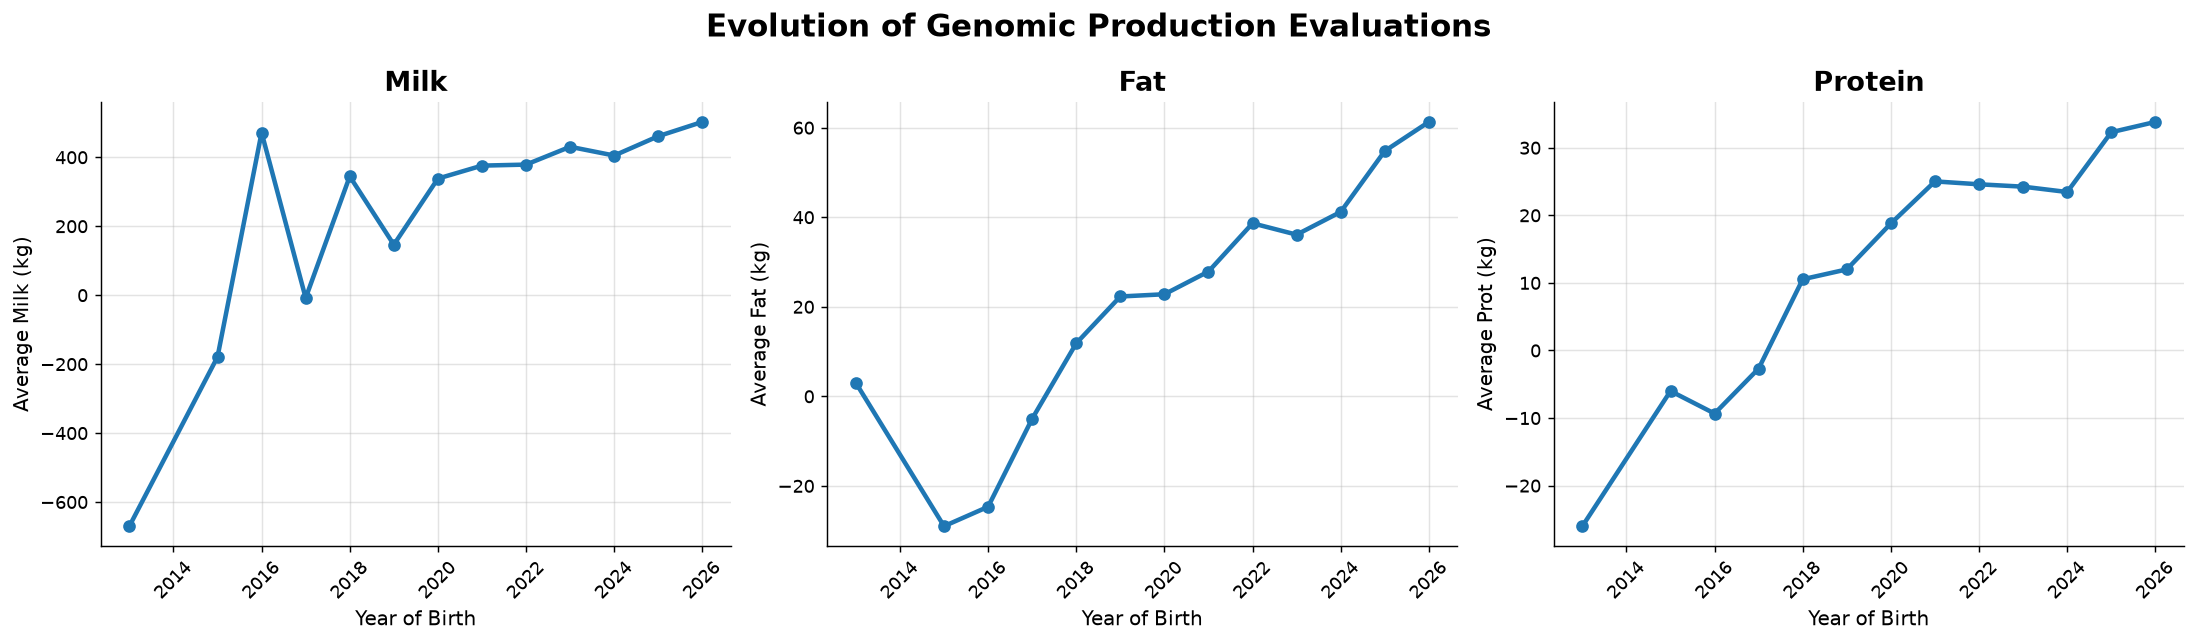

In [5]:
# ============================================================
# PRODUCTION TRAIT TRENDS IN ORIGINAL UNITS
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(17, 5),
    sharex=True
)

titles = {
    "Milk (kg)": "Milk",
    "Fat (kg)": "Fat",
    "Prot (kg)": "Protein"
}

for ax, column in zip(axes, production_columns):

    ax.plot(
        production_year.index,
        production_year[column],
        marker="o"
    )

    ax.set_title(titles[column])
    ax.set_xlabel("Year of Birth")
    ax.set_ylabel(f"Average {column}")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(
    "Evolution of Genomic Production Evaluations",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

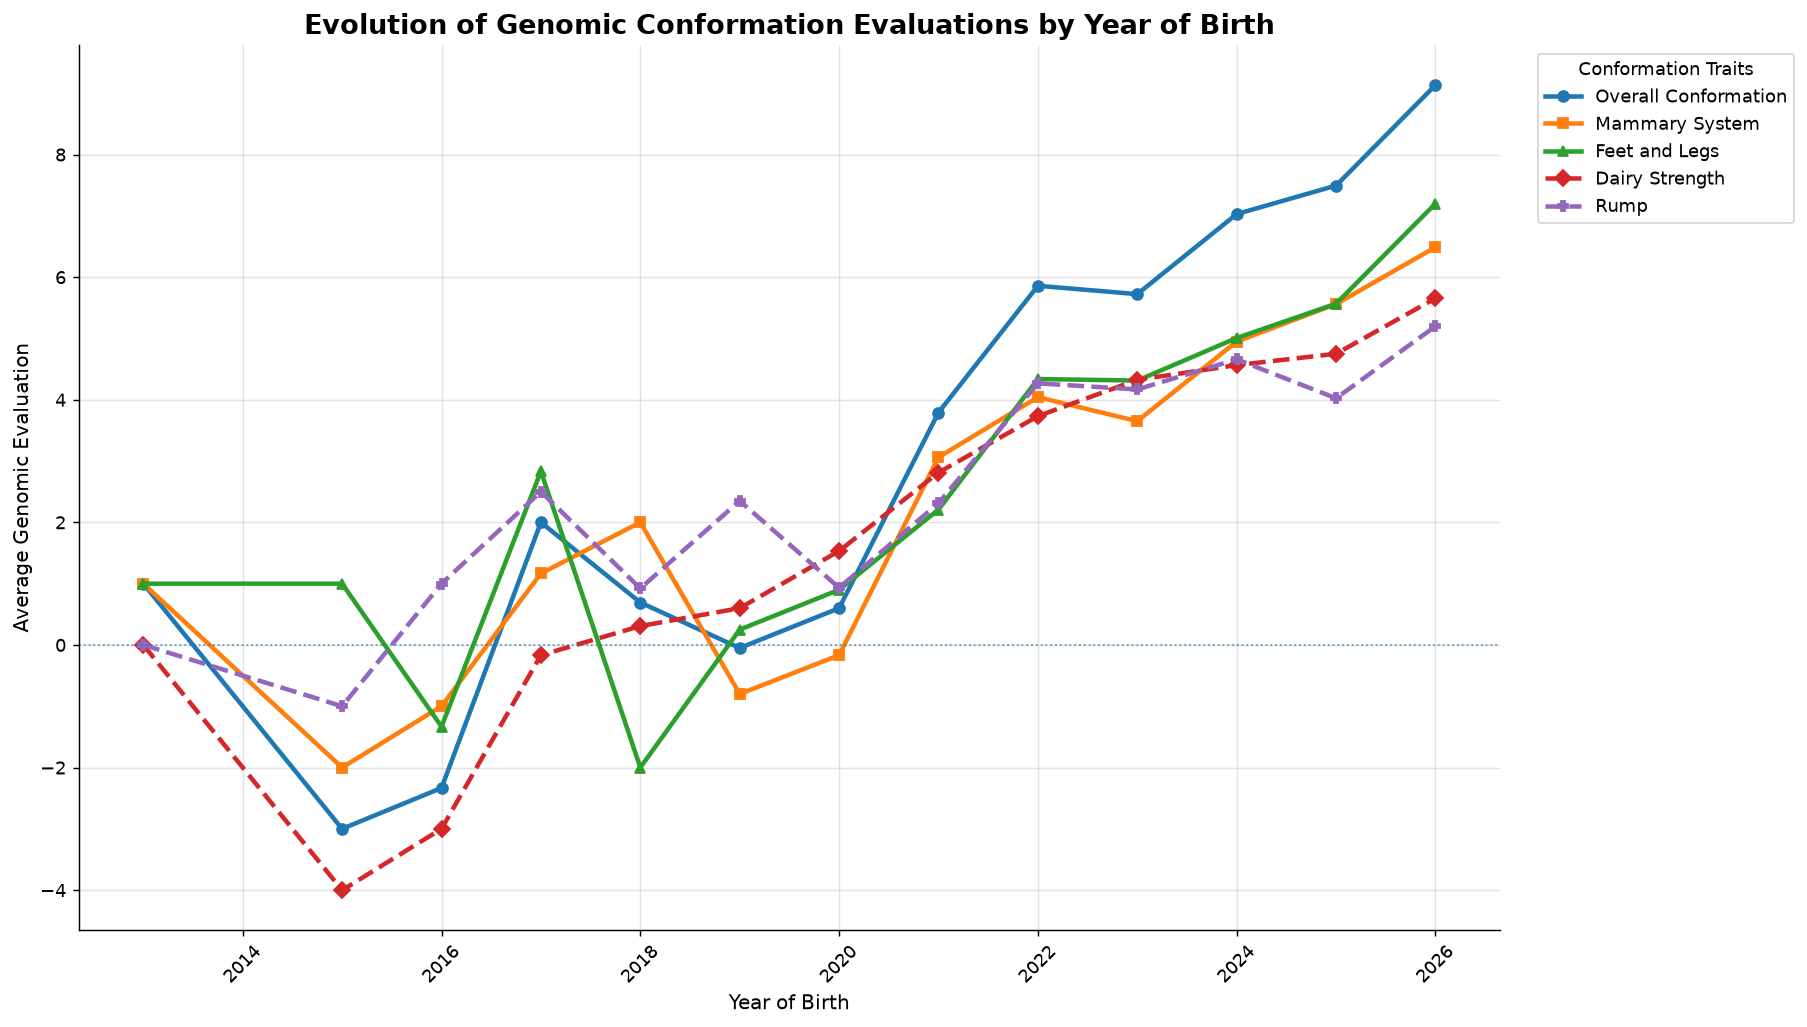

In [6]:
# ============================================================
# CONFORMATION TRAIT TRENDS
# ============================================================

conformation_columns = [
    "Conf",
    "MS",
    "FL",
    "DS",
    "RU"
]

conformation_year = (
    df.groupby("year")[conformation_columns]
      .mean()
      .sort_index()
)

labels = {
    "Conf": "Overall Conformation",
    "MS": "Mammary System",
    "FL": "Feet and Legs",
    "DS": "Dairy Strength",
    "RU": "Rump"
}

markers = {
    "Conf": "o",
    "MS": "s",
    "FL": "^",
    "DS": "D",
    "RU": "P"
}

line_styles = {
    "Conf": "-",
    "MS": "-",
    "FL": "-",
    "DS": "--",
    "RU": "--"
}

fig, ax = plt.subplots(figsize=(14, 8))

for column in conformation_columns:

    ax.plot(
        conformation_year.index,
        conformation_year[column],
        marker=markers[column],
        linestyle=line_styles[column],
        label=labels[column]
    )

ax.axhline(
    0,
    linewidth=1,
    linestyle=":",
    alpha=0.7
)

ax.set_title(
    "Evolution of Genomic Conformation Evaluations by Year of Birth"
)
ax.set_xlabel("Year of Birth")
ax.set_ylabel("Average Genomic Evaluation")
ax.tick_params(axis="x", rotation=45)

ax.legend(
    title="Conformation Traits",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

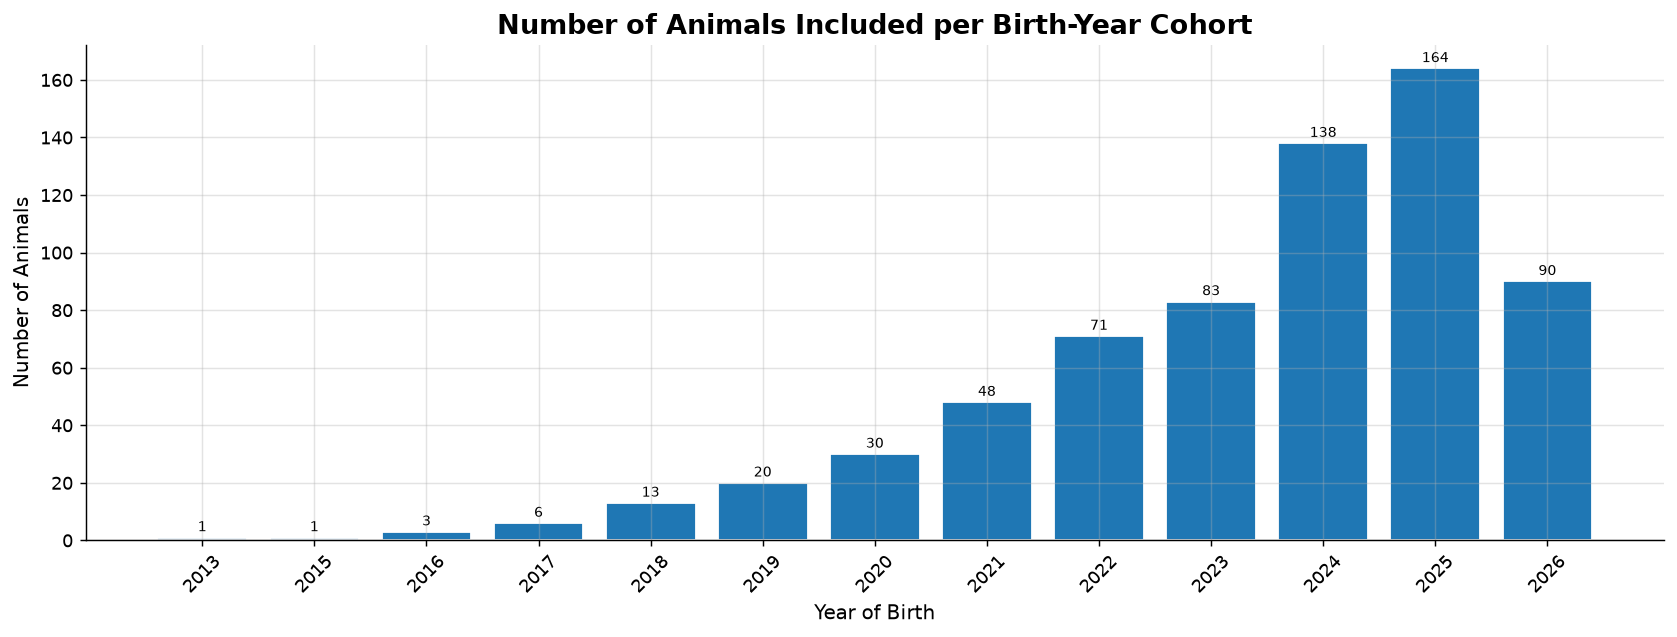

In [8]:
# ============================================================
# NUMBER OF ANIMALS PER BIRTH-YEAR COHORT
# ============================================================

cohort_size = (
    df["year"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(
    cohort_size.index.astype(int).astype(str),
    cohort_size.values,
    edgecolor="white"
)

ax.set_title(
    "Number of Animals Included per Birth-Year Cohort"
)
ax.set_xlabel("Year of Birth")
ax.set_ylabel("Number of Animals")
ax.tick_params(axis="x", rotation=45)

for bar in bars:
    value = int(bar.get_height())

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        str(value),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

GENETIC CHANGE BY BIRTH-YEAR COHORT (2018-2026)
Subindex      slope/yr     r2         p    2018    2026    total  H0
PROD            +12.43   0.94    0.0000   479.8   587.4   +107.7  REJECTED
L-TYPE          +23.86   0.94    0.0000   519.2   696.1   +176.9  REJECTED
HEALTH           +0.45   0.01    0.8063   527.0   537.5    +10.5  not rejected
M-ABILITY        +1.08   0.08    0.4620   471.1   494.0    +22.9  not rejected
REPRO            -5.67   0.39    0.0711   536.6   490.7    -45.9  not rejected
ENVIRO          -16.88   0.72    0.0036   616.5   478.0   -138.4  REJECTED

Selection indexes and production:
          LPI     Pro$  Milk (kg)  %Fat  %Prot
year                                          
2018  2919.08   658.15     344.62 -0.01  -0.01
2019  2897.45   638.15     146.40  0.14   0.06
2020  2964.43   816.10     338.17  0.08   0.06
2021  3103.44   909.62     375.79  0.11   0.10
2022  3191.01  1081.13     378.73  0.20   0.09
2023  3166.83   954.28     430.41  0.16   0.07
2024  3216

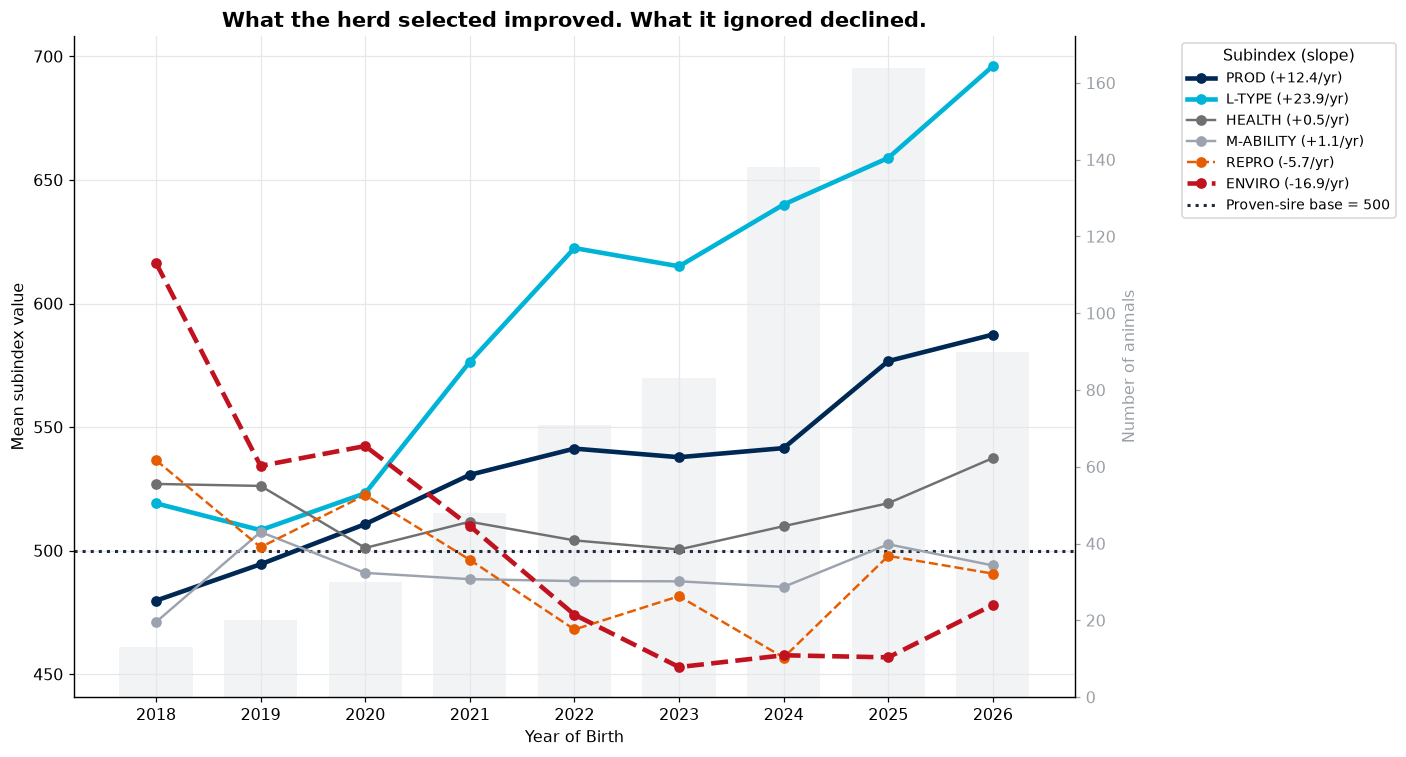

In [1]:
# =====================================================================
# 04.1 - WHAT CHANGED AND WHAT IMPROVED
# ---------------------------------------------------------------------
# WHAT WE EVALUATE:
#   Whether genetic merit differs across birth-year cohorts (2018-2026),
#   and in which direction, for each of the six LPI subindexes.
#
# H0: the slope of the subindex on birth year is zero (no genetic change).
# H1: slope != 0.
# DECISION RULE: reject H0 at p < 0.05 (linear regression on cohort means).
#
# IMPORTANT: all animals were evaluated on the SAME date. This compares
#   birth-year COHORTS, not longitudinal measurements. Cohorts before 2018
#   are excluded (2013 and 2015 have n = 1).
# =====================================================================
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats
os.makedirs("outputs", exist_ok=True)
plt.rcParams.update({"figure.dpi":110,"savefig.bbox":"tight","figure.facecolor":"white",
 "axes.titlesize":14,"axes.titleweight":"bold","axes.spines.top":False,
 "axes.grid":True,"grid.color":"#E5E7EB","axes.axisbelow":True,"font.size":10.5})

df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")
df.columns = [c.strip() for c in df.columns]
df["year"] = pd.to_datetime(df["Birth Date"], errors="coerce").dt.year

subidx = ["PROD","L-TYPE","HEALTH","M-ABILITY","REPRO","ENVIRO"]
for c in subidx + ["LPI","Pro$","Milk (kg)","%Fat","%Prot"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
sub    = df[df["year"] >= 2018]
trend  = sub.groupby("year")[subidx].mean()
counts = sub.groupby("year").size()

print("=" * 74); print("GENETIC CHANGE BY BIRTH-YEAR COHORT (2018-2026)"); print("=" * 74)
print(f"{'Subindex':12s} {'slope/yr':>9s} {'r2':>6s} {'p':>9s} {'2018':>7s} {'2026':>7s} {'total':>8s}  H0")
results = {}
for c in subidx:
    s = trend[c].dropna()
    slope, ic, r, p, se = stats.linregress(s.index, s.values)
    results[c] = {"slope": slope, "p": p, "r2": r**2}
    verdict = "REJECTED" if p < 0.05 else "not rejected"
    print(f"{c:12s} {slope:+9.2f} {r**2:6.2f} {p:9.4f} {s.iloc[0]:7.1f} {s.iloc[-1]:7.1f} "
          f"{s.iloc[-1]-s.iloc[0]:+8.1f}  {verdict}")

# selection indexes + production
g2 = sub.groupby("year")[["LPI","Pro$","Milk (kg)","%Fat","%Prot"]].mean()
print("\nSelection indexes and production:")
print(g2.round(2).to_string())

# ---- FIGURE: what the herd selected vs what it ignored ----
colors = {"L-TYPE":"#00b4d8","PROD":"#002855","HEALTH":"#707070",
          "M-ABILITY":"#9CA3AF","REPRO":"#e65c00","ENVIRO":"#c1121f"}
fig, ax1 = plt.subplots(figsize=(13, 7))
ax2 = ax1.twinx()
ax2.bar(counts.index, counts.values, color="#F1F3F5", width=0.7, zorder=0)
ax2.set_ylabel("Number of animals", color="#9AA0A6")
ax2.tick_params(axis="y", colors="#9AA0A6"); ax2.grid(False)
for c in subidx:
    sig = results[c]["p"] < 0.05
    ax1.plot(trend.index, trend[c], marker="o", ms=6,
             lw=3.0 if sig else 1.6, ls="-" if results[c]["slope"] > 0 else "--",
             color=colors[c], zorder=3, label=f"{c} ({results[c]['slope']:+.1f}/yr)")
ax1.axhline(500, ls=":", lw=2, color="#1F2937", zorder=2, label="Proven-sire base = 500")
ax1.set_zorder(ax2.get_zorder()+1); ax1.patch.set_visible(False)
ax1.set_title("What the herd selected improved. What it ignored declined.")
ax1.set_xlabel("Year of Birth"); ax1.set_ylabel("Mean subindex value")
ax1.set_xticks(trend.index)
ax1.legend(title="Subindex (slope)", bbox_to_anchor=(1.10, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.savefig("outputs/04_1_trends.png", dpi=150); plt.show()

In [2]:
# =====================================================================
# 04.2 - WHAT THE HERD IS NOT ACCOUNTING FOR
# ---------------------------------------------------------------------
# WHAT WE EVALUATE:
#   (a) Whether the decline in REPRO/ENVIRO is caused by antagonism with
#       production, or simply by not selecting for them.
#   (b) Whether type selection has increased body size, and what size costs.
#
# H0 (a): PROD is negatively correlated with REPRO/ENVIRO (antagonism
#         explains the decline).   H1 (a): correlation ~ 0 -> decline is
#         due to omission, not conflict.
# H0 (b): body size is unrelated to longevity, maintenance and environment
#         (rho = 0).               H1 (b): rho != 0.
# DECISION RULE: p < 0.05 (Pearson).
# =====================================================================
size_cols = ["STA","BD","HFE","CW"]
for c in size_cols + ["HL","BMR","Pro$","DF"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
z = df[size_cols].apply(lambda x: (x - x.mean()) / x.std())
df["SIZE"] = z.mean(axis=1)          # composite size index (linear traits only)

print("=" * 74); print("(a) IS THE DECLINE ANTAGONISM OR OMISSION?"); print("=" * 74)
for b in ["REPRO","ENVIRO","HEALTH"]:
    s = df[["PROD", b]].dropna(); r, p = stats.pearsonr(s["PROD"], s[b])
    sig = "***" if p < 0.001 else "*" if p < 0.05 else "ns"
    print(f"  PROD vs {b:8s} r = {r:+.3f} {sig:3s} -> "
          f"{'antagonism' if (r < -0.2 and p < 0.05) else 'NO antagonism: decline is by omission'}")

print("\n" + "=" * 74); print("(b) HAS TYPE SELECTION INCREASED SIZE?"); print("=" * 74)
for c in ["L-TYPE","STA","BD","HFE","SIZE"]:
    g = sub.groupby("year")[c].mean().dropna() if c != "SIZE" else \
        df[df["year"] >= 2018].groupby("year")["SIZE"].mean().dropna()
    slope, ic, r, p, se = stats.linregress(g.index, g.values)
    print(f"  {c:7s} slope={slope:+6.2f}/yr p={p:.4f}  {g.iloc[0]:+.2f} -> {g.iloc[-1]:+.2f}")

print("\n  What size costs (composite SIZE, all 668, no cutoff):")
for b in ["Milk (kg)","Fat (kg)","HL","BMR","ENVIRO","DF"]:
    s = df[["SIZE", b]].dropna(); r, p = stats.pearsonr(s["SIZE"], s[b])
    sig = "***" if p < 0.001 else "ns" if p >= 0.05 else "*"
    print(f"    SIZE vs {b:10s} r = {r:+.3f} {sig}")

(a) IS THE DECLINE ANTAGONISM OR OMISSION?
  PROD vs REPRO    r = -0.033 ns  -> NO antagonism: decline is by omission
  PROD vs ENVIRO   r = -0.093 *   -> NO antagonism: decline is by omission
  PROD vs HEALTH   r = +0.182 *** -> NO antagonism: decline is by omission

(b) HAS TYPE SELECTION INCREASED SIZE?
  L-TYPE  slope=+23.86/yr p=0.0000  +519.15 -> +696.08
  STA     slope= +0.23/yr p=0.0971  +1.00 -> +1.74
  BD      slope= +0.27/yr p=0.0003  +0.31 -> +2.56
  HFE     slope= +0.24/yr p=0.0216  +0.85 -> +2.28
  SIZE    slope= +0.05/yr p=0.0002  -0.26 -> +0.10

  What size costs (composite SIZE, all 668, no cutoff):
    SIZE vs Milk (kg)  r = +0.011 ns
    SIZE vs Fat (kg)   r = -0.210 ***
    SIZE vs HL         r = -0.424 ***
    SIZE vs BMR        r = -0.654 ***
    SIZE vs ENVIRO     r = -0.448 ***
    SIZE vs DF         r = -0.188 ***


C:\Users\arincon\AppData\Local\Temp\ipykernel_36120\3442298303.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["SIZE"] = z.mean(axis=1)          # composite size index (linear traits only)


# 04 — Genomic Trends

> **Research question:** where has this herd moved genetically, and did it pay?

All animals were evaluated on the same date, so this compares **birth-year cohorts**,
not longitudinal measurements. Cohorts before 2018 are excluded (2013 and 2015 contain
one animal each). Values are **genomic breeding values, not measured performance**.

---

## 1. What changed

Across eight cohorts (2018 → 2026), the herd moved decisively — but not uniformly.

| Subindex | Change/year | r² | p | 2018 → 2026 | H₀ (slope = 0) |
|---|---|---|---|---|---|
| **L-TYPE** | **+23.9** | 0.94 | <0.0001 | 519 → 696 | **rejected** |
| **PROD** | **+12.4** | 0.94 | <0.0001 | 480 → 587 | **rejected** |
| M-ABILITY | +1.1 | 0.08 | 0.46 | 471 → 494 | not rejected |
| HEALTH | +0.5 | 0.01 | 0.81 | 527 → 538 | not rejected |
| REPRO | **−5.7** | 0.39 | 0.071 | 537 → 491 | not rejected (marginal) |
| **ENVIRO** | **−16.9** | 0.72 | **0.0036** | 617 → 478 | **rejected** |

Two subindexes rose with near-perfect linearity (r² = 0.94). Two fell. Two stood still.
**Nothing stayed neutral by accident** — direction tracks selection emphasis exactly.

---

## 2. What improved

**The selection worked, and it paid.**

- **LPI: 2,919 → 3,492** (+20%)
- **Pro$: 658 → 1,609** (+145%) — profit grew more than twice as fast as the index
- **Milk: 345 → 503 kg**, while **%Fat rose −0.01 → +0.35** and **%Prot −0.01 → +0.13**

That last line matters: the herd gained **volume and concentration simultaneously**,
escaping the classic dilution trade-off (Milk vs %Fat is r = −0.41 *between animals*,
yet both rose *across cohorts* — selection overcame the antagonism).

**Verdict: the production programme is a success. This is not a failing herd.**

---

## 3. What the herd is not accounting for

**Reproduction and environment went backwards.** REPRO fell 46 points, ENVIRO fell 138.
Today the herd sits **below the proven-sire base (500)** on both:

| Subindex | Herd mean | Gap to base | % of animals below 500 |
|---|---|---|---|
| L-TYPE | 629.5 | **+129.5** | 7.9% |
| PROD | 549.0 | +49.0 | 25.6% |
| HEALTH | 514.4 | +14.4 | 44.2% |
| M-ABILITY | 492.7 | −7.3 | 53.3% |
| **REPRO** | **485.6** | **−14.4** | **55.7%** |
| **ENVIRO** | **476.6** | **−23.4** | **63.2%** |

**The decline is not antagonism — it is omission.** PROD vs REPRO is **r = −0.03 (ns)**
and PROD vs ENVIRO **r = −0.09**. Production is not dragging these traits down.
**Nobody is selecting for them.** Because genetic change is cumulative, the loss
compounds and is not recoverable through management.

**The hidden driver: body size.** Type selection (+23.9/yr) has made the herd bigger —
Body Depth **+0.27/yr (p = 0.0003)**, Height at Front End **+0.24/yr (p = 0.022)**. And
size is antagonistic to almost everything that pays:

| Composite SIZE vs | r |
|---|---|
| **Milk yield** | **+0.01 (ns)** — size buys no milk |
| Fat yield | −0.210*** |
| Herd Life | −0.424*** |
| **Body Maintenance** | **−0.654*** |
| Environmental Impact | −0.448*** |
| Daughter Fertility | −0.188*** |

**The herd has been selecting for a trait that delivers no additional milk while
costing components, longevity, fertility and feed.** This is the mechanism behind the
ENVIRO collapse.

---

## 4. Where the opportunity is

**The decisive question:** is the trade-off a biological constraint, or a choice?

**H₀:** no animals exist that combine high production, adequate reproduction and
moderate size. **H₀ is rejected.**

- Of the **171 animals in the top production quartile**, **68 (39.8%) already have
  REPRO ≥ 500**.
- **45 animals (6.7% of the herd)** combine **top-quartile PROD + REPRO ≥ 500 +
  below-average size**.

**These animals are not a compromise — they are the best animals in the herd:**

| | Elite subgroup (n=45) | Herd average | Difference |
|---|---|---|---|
| PROD | **643** | 549 | **+94** |
| REPRO | **552** | 486 | **+66** |
| ENVIRO | **498** | 477 | **+21** |
| Herd Life | **104.8** | 102.5 | **+2.3** |
| **Pro$** | **2,146** | 1,145 | **+1,001** |

**They are worth 87% more Pro$ than the herd average — while being smaller, more
fertile and more environmentally efficient.**

**And fixing reproduction is free — in fact it pays:**

| REPRO vs | r | Cost of selecting for it |
|---|---|---|
| PROD | −0.03 (ns) | **free** — no production sacrificed |
| L-TYPE | −0.03 (ns) | **free** — no type sacrificed |
| Pro$ | **+0.278*** | **it pays** — positively linked to profit |
| LPI | +0.191*** | it pays |

---

## Recommendation

1. **Keep the production programme.** It works: +145% Pro$ in eight cohorts.
2. **Add a REPRO ≥ 500 threshold** to sire filtering. The data shows this costs nothing
   in production or type (r ≈ −0.03, ns) and is positively associated with profit
   (r = +0.28).
3. **Cap body size.** Stop treating size as a free by-product of type selection.
   Continue selecting for the functional type traits that pay (Locomotion r = +0.24
   with Herd Life; Front Legs View r = +0.33 with Pro$) and apply negative pressure to
   Stature and Body Depth.
4. **Use the herd's own 45 elite animals as the breeding template.** The solution does
   not need to be imported — it already exists inside the herd.

---

## Caveats

Genomic evaluations, not measured performance. Cohort comparisons, not longitudinal
data. The REPRO slope (p = 0.071) and the Stature slope (p = 0.097) are **not
significant at α = 0.05** and are reported as directional. Correlations describe
association within this herd (n = 668) and are not causal. Pro$ contains a
body-size-linked maintenance cost term (Lactanet does not publish the formula), so
size–Pro$ relationships are partly structural; the fat, protein, Herd Life and BMR
results are independent of that caveat.

1. SELECTION INDEXES
Trait         slope/yr     r2        p     first      last  H0
LPI             +71.86   0.94   0.0000   2919.08   3492.32  REJECTED
Pro$           +109.99   0.86   0.0003    658.15   1608.81  REJECTED


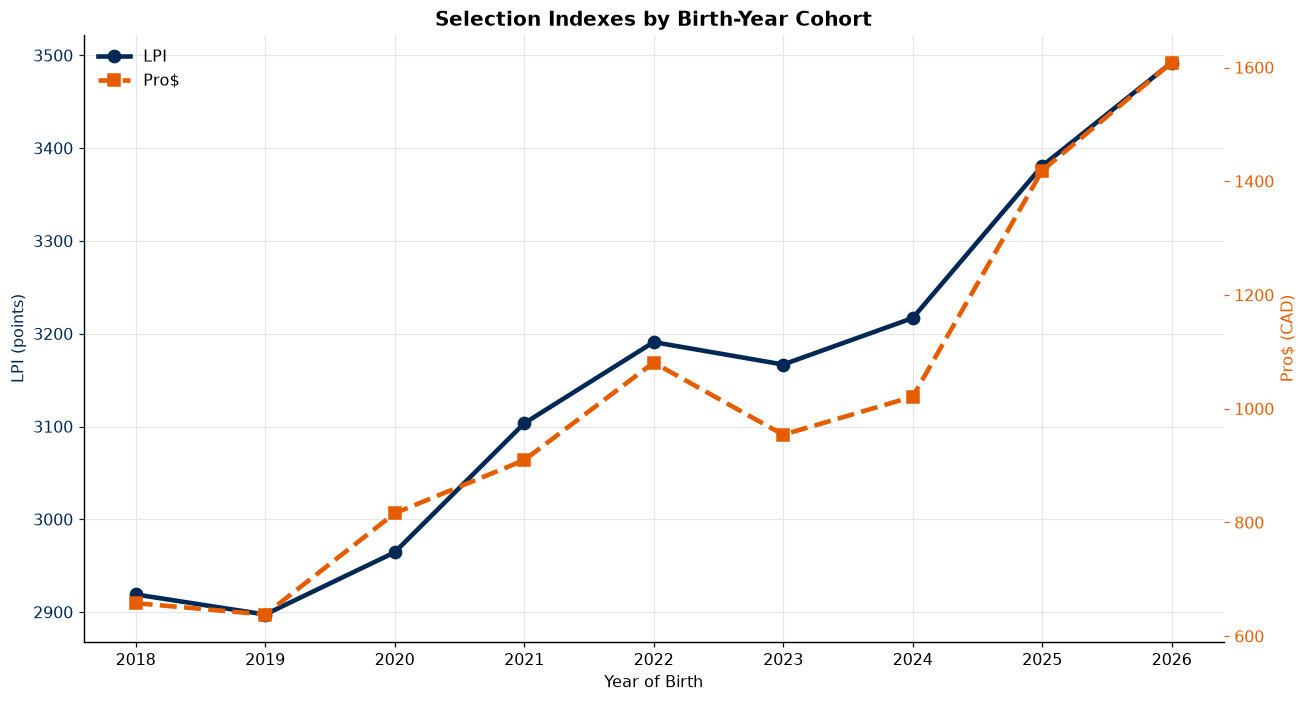


2. PRODUCTION TRAITS
Trait         slope/yr     r2        p     first      last  H0
Milk (kg)       +29.40   0.63   0.0105    344.62    502.53  REJECTED
Fat (kg)         +5.67   0.95   0.0000     11.85     61.29  REJECTED
Prot (kg)        +2.71   0.87   0.0002     10.54     33.82  REJECTED
%Fat             +0.04   0.85   0.0004     -0.01      0.35  REJECTED
%Prot            +0.01   0.72   0.0040     -0.01      0.13  REJECTED


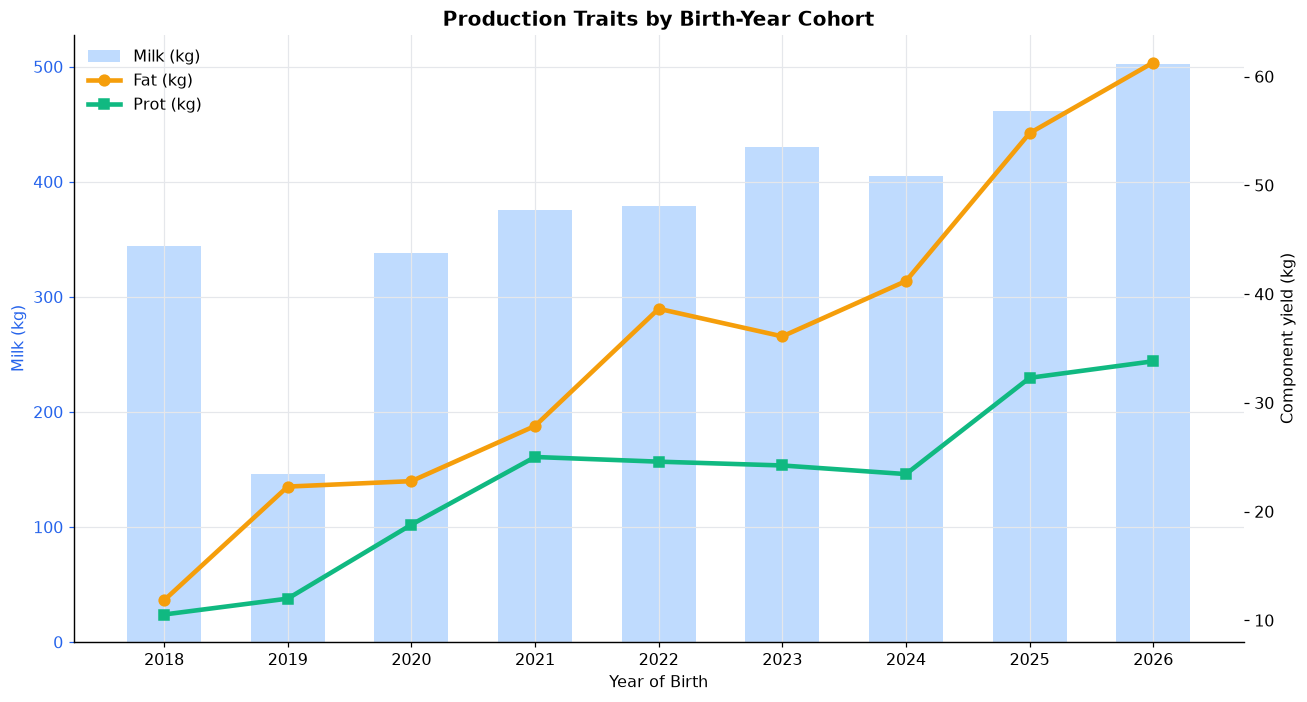


3. CONFORMATION TRAITS
Trait         slope/yr     r2        p     first      last  H0
Conf             +1.19   0.93   0.0000      0.69      9.13  REJECTED
MS               +0.80   0.78   0.0017      2.00      6.49  REJECTED
FL               +1.05   0.96   0.0000     -2.00      7.20  REJECTED
DS               +0.69   0.96   0.0000      0.31      5.66  REJECTED
RU               +0.52   0.80   0.0012      0.92      5.20  REJECTED


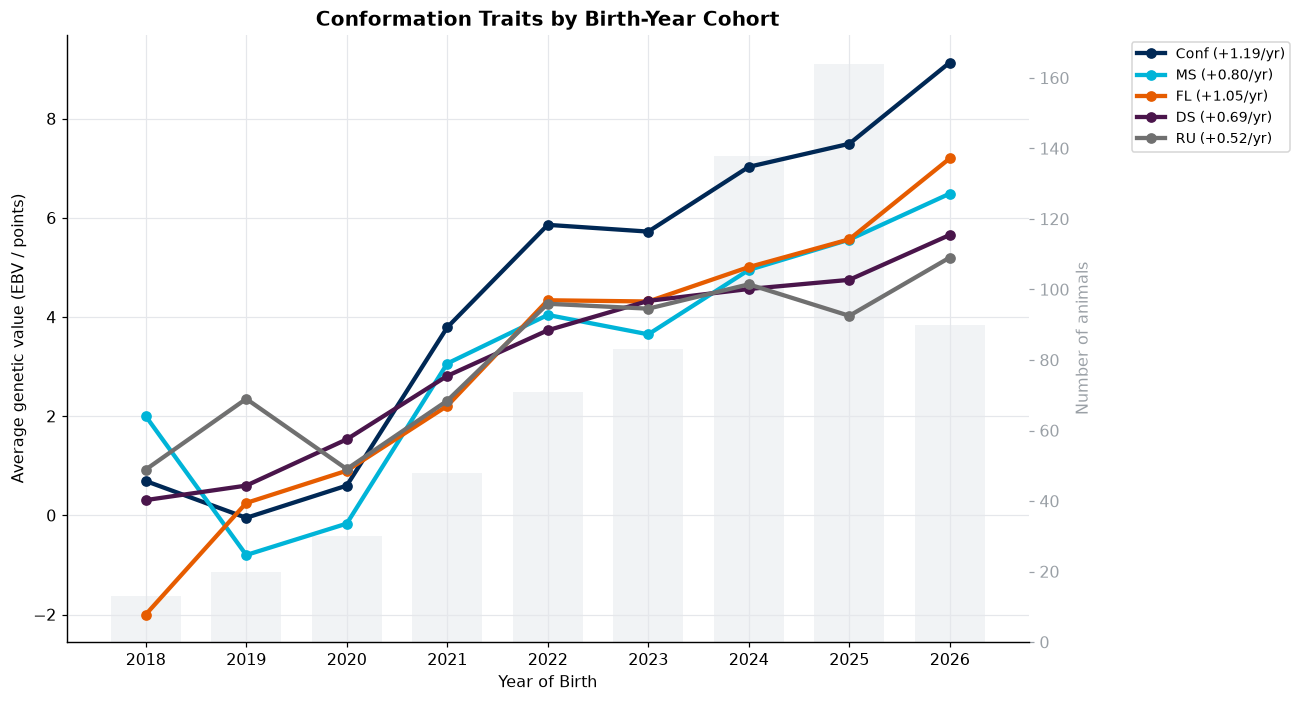


4. INBREEDING - PEDIGREE vs GENOMIC
Inb.%            slope=+0.363/yr r2=0.87 p=0.0002  5.98% -> 8.54%  (9 cohorts)  H0 REJECTED
Genomic Inb. %   slope=+0.556/yr r2=0.92 p=0.0022  10.18% -> 13.37%  (6 cohorts)  H0 REJECTED


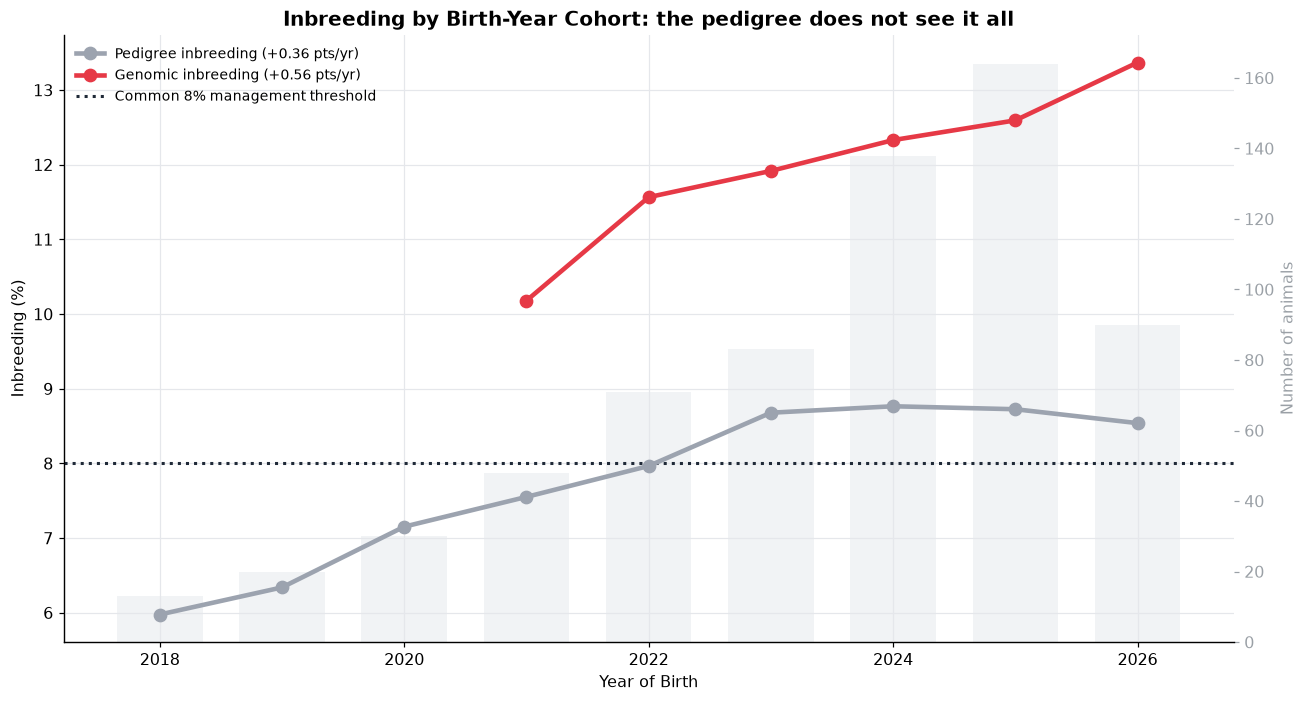

In [6]:
# =====================================================================
# 04 - GENOMIC TRENDS
# ---------------------------------------------------------------------
# WHAT WE EVALUATE:
#   Whether the mean genomic evaluation differs across birth-year cohorts
#   (2018-2026) for: (1) selection indexes, (2) production traits,
#   (3) conformation traits, (4) inbreeding.
#
# H0: the slope of the trait on birth year is zero (no change across cohorts).
# H1: slope != 0.
# DECISION RULE: reject H0 at p < 0.05 (OLS on cohort means).
#
# SCOPE: descriptive. These are cohort means of genomic evaluations from ONE
#   herd, NOT population genetic trends estimated with a genetic model, and
#   NOT measured performance. Cohorts before 2018 excluded (n = 1 each).
# =====================================================================
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats
os.makedirs("outputs", exist_ok=True)
plt.rcParams.update({"figure.dpi":110,"savefig.bbox":"tight","figure.facecolor":"white",
 "axes.titlesize":13,"axes.titleweight":"bold","axes.spines.top":False,
 "axes.spines.right":False,"axes.grid":True,"grid.color":"#E5E7EB",
 "axes.axisbelow":True,"font.size":10.5})

df = pd.read_excel("../Master_Database_Consolidated_Final.xlsx")
df.columns = [c.strip() for c in df.columns]
df["year"] = pd.to_datetime(df["Birth Date"], errors="coerce").dt.year
cols = ["LPI","Pro$","Milk (kg)","Fat (kg)","Prot (kg)","%Fat","%Prot",
        "Conf","MS","FL","DS","RU","Genomic Inb. %","Inb.%"]
for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
sub    = df[df["year"] >= 2018]
counts = sub.groupby("year").size()

def trend_test(series):
    s = series.dropna()
    r = stats.linregress(s.index, s.values)
    return {"slope": r.slope, "p": r.pvalue, "r2": r.rvalue**2,
            "first": s.iloc[0], "last": s.iloc[-1], "n_years": len(s)}

def report(group, traits, title):
    print("=" * 76); print(title); print("=" * 76)
    print(f"{'Trait':12s} {'slope/yr':>9s} {'r2':>6s} {'p':>8s} {'first':>9s} {'last':>9s}  H0")
    out = {}
    for c in traits:
        t = trend_test(group.groupby("year")[c].mean())
        out[c] = t
        v = "REJECTED" if t["p"] < 0.05 else "not rejected"
        print(f"{c:12s} {t['slope']:+9.2f} {t['r2']:6.2f} {t['p']:8.4f} "
              f"{t['first']:9.2f} {t['last']:9.2f}  {v}")
    return out

def dual_plot(traits, colors, title, ylab, fname, group=None):
    g = (group if group is not None else sub)
    tr = g.groupby("year")[traits].mean()
    fig, ax1 = plt.subplots(figsize=(12, 6.5))
    ax2 = ax1.twinx()
    ax2.bar(counts.index, counts.values, color="#F1F3F5", width=0.7, zorder=0)
    ax2.set_ylabel("Number of animals", color="#9AA0A6")
    ax2.tick_params(axis="y", colors="#9AA0A6"); ax2.grid(False)
    for c in traits:
        t = trend_test(tr[c])
        ax1.plot(tr.index, tr[c], marker="o", ms=6, lw=2.8 if t["p"] < 0.05 else 1.6,
                 color=colors[c], zorder=3, label=f"{c} ({t['slope']:+.2f}/yr)")
    ax1.set_zorder(ax2.get_zorder()+1); ax1.patch.set_visible(False)
    ax1.set_title(title); ax1.set_xlabel("Year of Birth"); ax1.set_ylabel(ylab)
    ax1.set_xticks(tr.index)
    ax1.legend(bbox_to_anchor=(1.10, 1), loc="upper left", fontsize=9)
    plt.tight_layout(); plt.savefig(f"outputs/{fname}", dpi=150); plt.show()

# ---------- BLOCK 1: SELECTION INDEXES ----------
r1 = report(sub, ["LPI","Pro$"], "1. SELECTION INDEXES")
fig, ax1 = plt.subplots(figsize=(12, 6.5))
g = sub.groupby("year")[["LPI","Pro$"]].mean()
ax1.plot(g.index, g["LPI"], marker="o", lw=3, ms=8, color="#002855", label="LPI")
ax1.set_ylabel("LPI (points)", color="#002855"); ax1.tick_params(axis="y", colors="#002855")
ax2 = ax1.twinx()
ax2.plot(g.index, g["Pro$"], marker="s", lw=3, ms=8, ls="--", color="#e65c00", label="Pro$")
ax2.set_ylabel("Pro$ (CAD)", color="#e65c00"); ax2.tick_params(axis="y", colors="#e65c00")
ax2.grid(False)
ax1.set_title("Selection Indexes by Birth-Year Cohort"); ax1.set_xlabel("Year of Birth")
ax1.set_xticks(g.index)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper left", frameon=False)
plt.tight_layout(); plt.savefig("outputs/04_1_indexes.png", dpi=150); plt.show()

# ---------- BLOCK 2: PRODUCTION ----------
r2 = report(sub, ["Milk (kg)","Fat (kg)","Prot (kg)","%Fat","%Prot"], "\n2. PRODUCTION TRAITS")
fig, ax1 = plt.subplots(figsize=(12, 6.5))
g = sub.groupby("year")[["Milk (kg)","Fat (kg)","Prot (kg)","%Fat","%Prot"]].mean()
ax1.bar(g.index, g["Milk (kg)"], color="#BFDBFE", width=0.6, label="Milk (kg)", zorder=0)
ax1.set_ylabel("Milk (kg)", color="#2563EB"); ax1.tick_params(axis="y", colors="#2563EB")
ax2 = ax1.twinx()
for c, col, mk in [("Fat (kg)","#F59E0B","o"), ("Prot (kg)","#10B981","s")]:
    ax2.plot(g.index, g[c], marker=mk, lw=3, ms=7, color=col, label=c, zorder=3)
ax2.set_ylabel("Component yield (kg)"); ax2.grid(False)
ax1.set_zorder(0); ax2.set_zorder(1); ax1.patch.set_visible(False)
ax1.set_title("Production Traits by Birth-Year Cohort"); ax1.set_xlabel("Year of Birth")
ax1.set_xticks(g.index)
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left", frameon=False)
plt.tight_layout(); plt.savefig("outputs/04_2_production.png", dpi=150); plt.show()

# ---------- BLOCK 3: CONFORMATION ----------
r3 = report(sub, ["Conf","MS","FL","DS","RU"], "\n3. CONFORMATION TRAITS")
dual_plot(["Conf","MS","FL","DS","RU"],
          {"Conf":"#002855","MS":"#00b4d8","FL":"#e65c00","DS":"#4a154b","RU":"#707070"},
          "Conformation Traits by Birth-Year Cohort",
          "Average genetic value (EBV / points)", "04_3_conformation.png")

# ---------- BLOCK 4: INBREEDING (pedigree vs genomic) ----------
print("\n" + "=" * 76); print("4. INBREEDING - PEDIGREE vs GENOMIC"); print("=" * 76)
for c in ["Inb.%", "Genomic Inb. %"]:
    g_ = sub[sub[c].notna()].groupby("year")[c].mean()
    t = trend_test(g_)
    v = "REJECTED" if t["p"] < 0.05 else "not rejected"
    print(f"{c:16s} slope={t['slope']:+.3f}/yr r2={t['r2']:.2f} p={t['p']:.4f}  "
          f"{t['first']:.2f}% -> {t['last']:.2f}%  ({t['n_years']} cohorts)  H0 {v}")

fig, ax1 = plt.subplots(figsize=(12, 6.5))
ax2 = ax1.twinx()
ax2.bar(counts.index, counts.values, color="#F1F3F5", width=0.7, zorder=0)
ax2.set_ylabel("Number of animals", color="#9AA0A6")
ax2.tick_params(axis="y", colors="#9AA0A6"); ax2.grid(False)
for c, col, lbl in [("Inb.%","#9CA3AF","Pedigree inbreeding"),
                    ("Genomic Inb. %","#E63946","Genomic inbreeding")]:
    g_ = sub[sub[c].notna()].groupby("year")[c].mean()
    t = trend_test(g_)
    ax1.plot(g_.index, g_.values, marker="o", lw=3, ms=8, color=col,
             label=f"{lbl} ({t['slope']:+.2f} pts/yr)", zorder=3)
ax1.axhline(8, ls=":", lw=2, color="#1F2937", label="Common 8% management threshold")
ax1.set_zorder(ax2.get_zorder()+1); ax1.patch.set_visible(False)
ax1.set_title("Inbreeding by Birth-Year Cohort: the pedigree does not see it all")
ax1.set_xlabel("Year of Birth"); ax1.set_ylabel("Inbreeding (%)")
ax1.legend(loc="upper left", frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig("outputs/04_4_inbreeding.png", dpi=150); plt.show()

# 04 — Genomic Trends

## Objective

Evaluate how genomic evaluations for selection indexes (LPI, Pro$), production traits,
conformation traits, and inbreeding changed across birth-year cohorts (2018–2026) in
the evaluated Holstein population (n = 668).

## Scope

This notebook is **descriptive**. Functional subindexes (PROD, HEALTH, L-TYPE, REPRO,
M-ABILITY, ENVIRO), body size and their strategic implications are analysed separately
in notebook 05.

## Important methodological note

These figures show changes in the average genomic evaluations of animals included in
the database by year of birth. They do not represent actual milk production, observed
conformation, or population-level genetic trends estimated using a genetic model.

Three limitations follow:

- **Single herd, not a population.** Cohort means are not representative of the
  Canadian Holstein population.
- **Survivorship.** The database contains animals currently present. Culled or sold
  animals are absent, so earlier cohorts are a **surviving subset** — which may inflate
  older cohort means and *understate* real progress.
- **Single evaluation date.** All animals were evaluated on the same date under the
  same models. Cohort differences reflect the merit of animals born in each year, not
  evaluations made at the time.

Cohorts before 2018 are excluded: 2013 and 2015 contain one animal each.

**Statistical test.** H₀: slope on birth year = 0. H₁: slope ≠ 0. Rejected at p < 0.05
(OLS on cohort means, 9 points).

---

## 1. Selection indexes

| Index | Slope/year | r² | p | 2018 → 2026 | Change | H₀ |
|---|---|---|---|---|---|---|
| **LPI** | **+71.9** | 0.94 | <0.0001 | 2,919 → 3,492 | **+20%** | rejected |
| **Pro$** | **+110.0** | 0.86 | 0.0003 | 658 → 1,609 | **+144%** | rejected |

Both indexes rose with strong linearity. **Pro$ grew seven times faster in relative
terms than LPI** (+144% vs +20%) — the herd's profit merit advanced far more than its
composite index score, indicating selection aligned with economic rather than
index-balanced goals.

---

## 2. Production traits

| Trait | Slope/year | r² | p | 2018 → 2026 | H₀ |
|---|---|---|---|---|---|
| **Fat (kg)** | **+5.67** | 0.95 | <0.0001 | 11.9 → **61.3** | rejected |
| **Prot (kg)** | **+2.71** | 0.87 | 0.0002 | 10.5 → **33.8** | rejected |
| Milk (kg) | +29.40 | 0.63 | 0.0105 | 344.6 → 502.5 | rejected |
| %Fat | +0.04 | 0.85 | 0.0004 | −0.01 → **+0.35** | rejected |
| %Prot | +0.01 | 0.72 | 0.0040 | −0.01 → **+0.13** | rejected |

**The strongest and cleanest trend in the entire dataset is Fat yield** (r² = 0.95):
genomic merit for fat rose **from 11.9 to 61.3 kg — more than fivefold**. Protein
tripled.

Critically, **volume and concentration rose together**. Between animals, milk volume is
negatively correlated with %Fat (r = −0.41) — the classic dilution antagonism. Across
cohorts, both increased. Selection overcame the trade-off, which is only possible when
selection targets **component yield** rather than volume. The data confirms this:
Fat and Protein have the highest r² of any production trait, while Milk has the lowest
(0.63) and the weakest p-value (0.0105).

---

## 3. Conformation traits

| Trait | Slope/year | r² | p | 2018 → 2026 | H₀ |
|---|---|---|---|---|---|
| **Conf** (overall) | **+1.19** | 0.93 | <0.0001 | +0.7 → **+9.1** | rejected |
| **FL** (Feet & Legs) | **+1.05** | **0.96** | <0.0001 | **−2.0 → +7.2** | rejected |
| MS (Mammary System) | +0.80 | 0.78 | 0.0017 | +2.0 → +6.5 | rejected |
| DS (Dairy Strength) | +0.69 | 0.96 | <0.0001 | +0.3 → +5.7 | rejected |
| RU (Rump) | +0.52 | 0.80 | 0.0012 | +0.9 → +5.2 | rejected |

**All five conformation traits improved significantly.** Overall Conformation rose
**8.4 points in eight cohorts** with r² = 0.93.

The largest transformation is **Feet & Legs**, which moved from **negative (−2.0) to
+7.2** — the only trait that started below the base and ended clearly above it, with the
tightest fit in the notebook (r² = 0.96). Every pillar advanced; none was sacrificed.

*Note: Conf is a composite of MS, FL, DS and RU. It is reported here as the summary
measure, not as independent evidence alongside its own components.*

---

## 4. Inbreeding — and what the pedigree cannot see

| Measure | Slope/year | r² | p | Range | Cohorts | H₀ |
|---|---|---|---|---|---|---|
| Pedigree (`Inb.%`) | **+0.363** | 0.87 | 0.0002 | 5.98% → **8.54%** | 2018–2026 (9) | rejected |
| **Genomic (`Genomic Inb. %`)** | **+0.556** | 0.92 | 0.0022 | 10.18% → **13.37%** | 2021–2026 (6) | rejected |

Both measures rise significantly — but **not at the same speed**.

**Genomic inbreeding is climbing 53% faster than pedigree inbreeding**
(+0.556 vs +0.363 points/year). The gap between what the pedigree reports and what the
genome contains is **widening**, not stable.

**The most consequential detail is in the last three cohorts.** Pedigree inbreeding
**plateaued and began to fall** — 8.77% (2024) → 8.73% (2025) → **8.54% (2026)** —
while genomic inbreeding **kept rising**: 12.33% → 12.59% → **13.37%**.

> A breeder monitoring pedigree inbreeding would conclude the herd had stabilised below
> the 8% threshold. The genome says inbreeding reached its **highest level ever** in the
> youngest cohort.

Pedigree inbreeding never crosses the common **8% management threshold** in any cohort.
Genomic inbreeding **starts above it and never returns**.

---

## Summary

Across eight birth-year cohorts, this herd:

1. **Improved every index and every trait it selected for.** LPI +20%, Pro$ +144%,
   Fat yield more than fivefold, all five conformation pillars significantly up.
2. **Escaped the dilution trade-off** by selecting component yield rather than volume —
   %Fat and %Prot both moved from negative to positive.
3. **Rebuilt Feet & Legs from −2.0 to +7.2**, the single largest turnaround.
4. **Accumulated inbreeding faster than its pedigree reveals**, with the divergence
   growing and the youngest cohort at its genomic maximum (13.37%).

**The genetic programme is working. Its cost is being measured with the wrong
instrument.**

---

## Caveats

Genomic evaluations, not measured performance. Cohort means from a single herd, not
model-estimated population trends. Trend tests use 9 cohort means (6 for genomic
inbreeding, unavailable before 2021), so slopes are estimated from few points and are
sensitive to cohort size — early cohorts are small (2018: n = 13) and subject to
survivorship.